In [2]:
import h5py
import numpy as np
import torch
import torch.nn as nn
from tqdm import trange
from torch.autograd import grad, Variable

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
print(f"Using device: {device}")

torch.manual_seed(1234)

Using device: cuda


In [4]:
#reading file
with h5py.File('ProblemA_dataset.h5', 'r') as file:
    print("Keys in dataset:", list(file.keys()))
    u_obs = torch.tensor(file['u_obs'][:], dtype=dtype).reshape(-1, 1)
    x_obs = torch.tensor(file['x_obs'][:], dtype=dtype).reshape(-1, 1)
    u_test = torch.tensor(file['u_test'][:], dtype=dtype).reshape(-1, 1)
    x_test = torch.tensor(file['x_test'][:], dtype=dtype).reshape(-1, 1)
    k_test = torch.tensor(file['k_test'][:], dtype=dtype).reshape(-1, 1)

n_pde = 2000
x_pde = torch.linspace(0, 1, n_pde, dtype=dtype).reshape(-1, 1)
print("\nObservation dataset:")
print("Size of u_obs:", u_obs.shape)
print("Size of x_obs:", x_obs.shape)
print("\nTesting dataset-")
print("Size of u_test:", u_test.shape)
print("Size of x_test:", x_test.shape)
print("Size of k_test:", k_test.shape)

Keys in dataset: ['k_test', 'u_obs', 'u_test', 'x_obs', 'x_test']

Observation dataset:
Size of u_obs: torch.Size([500, 1])
Size of x_obs: torch.Size([500, 1])

Testing dataset-
Size of u_test: torch.Size([10001, 1])
Size of x_test: torch.Size([10001, 1])
Size of k_test: torch.Size([10001, 1])


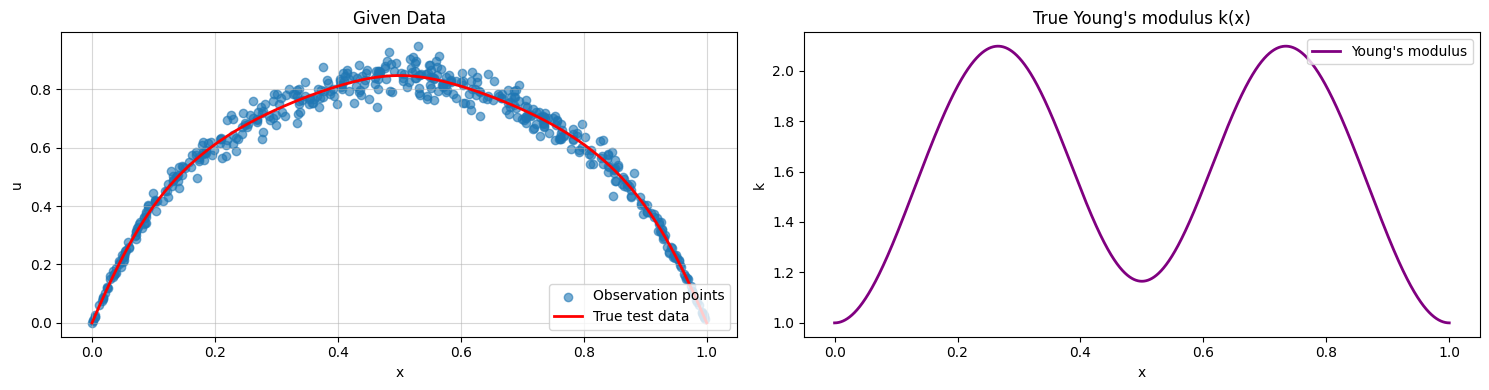

In [5]:
#data charts
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].scatter(x_obs.numpy(), u_obs.numpy(), label="Observation points", alpha=0.6)
axs[0].plot(x_test.numpy(), u_test.numpy(), color="red", label="True test data", linewidth=2)
axs[0].set_title("Given Data")
axs[0].grid(True, linestyle='-', alpha=0.5)
axs[0].set_xlabel("x")
axs[0].set_ylabel("u")
axs[0].legend(loc="lower right")
axs[1].plot(x_test.numpy(), k_test.numpy(), color="purple", label="Young's modulus", linewidth=2)
axs[1].set_title("True Young's modulus k(x)")
axs[1].set_xlabel("x")
axs[1].set_ylabel("k")
axs[1].legend(loc='upper right')
plt.tight_layout()
plt.show()

In [6]:
#training
class simpleMLP(nn.Module):
    def __init__(self, layers: list, is_k=False):
        super().__init__()
        self.is_k = is_k
        self.net = nn.ModuleList()
        hidden_in = layers[0]
        for hidden_out in layers[1:]:
            self.net.append(nn.Linear(hidden_in, hidden_out, dtype=dtype))
            hidden_in = hidden_out

    def forward(self, x):
        for layer in self.net[:-1]:
            x = torch.tanh(layer(x))
        x = self.net[-1](x)
        if self.is_k:
            return torch.exp(x)
        return x

class loss_class(object):
    def __init__(self, u_model, k_model, x_pde, x_obs, u_obs, f=9.81, device="cpu"):
        self.u_model = u_model.to(device)
        self.k_model = k_model.to(device)
        self.x_pde = Variable(x_pde, requires_grad=True).to(device)
        self.x_obs = x_obs.to(device)
        self.u_obs = u_obs.to(device)
        self.x_bd = torch.tensor([[0.], [1.]], device=device)
        self.u_bd = torch.tensor([[0.], [0.]], device=device)
        self.f = f
        self.mse = nn.MSELoss()

    def _pde_loss(self):
        u = self.u_model(self.x_pde)
        k = self.k_model(self.x_pde)
        du_dx = grad(inputs=self.x_pde, outputs=u, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        flux = k * du_dx
        dflux_dx = grad(inputs=self.x_pde, outputs=flux, grad_outputs=torch.ones_like(flux), create_graph=True)[0]
        residual = -dflux_dx - self.f
        return torch.mean(residual**2)

    def _bd_loss(self):
        u_pred_bd = self.u_model(self.x_bd)
        return self.mse(u_pred_bd, self.u_bd)

    def _data_loss(self):
        u_pred_obs = self.u_model(self.x_obs)
        return self.mse(u_pred_obs, self.u_obs)

    def __call__(self, w_pde, w_data, w_bd):
        loss = 0.0
        loss += self._pde_loss() * w_pde
        loss += self._data_loss() * w_data
        loss += self._bd_loss() * w_bd
        return loss

class error_class(object):
    def __init__(self, u_model, k_model, x_test, u_test, k_test, device="cpu"):
        self.u_model = u_model.to(device)
        self.k_model = k_model.to(device)
        self.x_test = x_test.to(device)
        self.u_test = u_test.to(device)
        self.k_test = k_test.to(device)

    def _error_k(self):
        k_pred = self.k_model(self.x_test)
        num = torch.sum((k_pred - self.k_test)**2)
        den = torch.sum(self.k_test**2)
        return torch.sqrt(num/den)

    def _error_u(self):
        u_pred = self.u_model(self.x_test)
        num = torch.sum((u_pred - self.u_test)**2)
        den = torch.sum(self.u_test**2)
        return torch.sqrt(num/den)

    def __call__(self):
        error_u = self._error_u()
        error_k = self._error_k()
        return error_u, error_k

u_model = simpleMLP([1, 50, 50, 50, 50, 1], is_k=False).to(device)
k_model = simpleMLP([1, 50, 50, 50, 50, 1], is_k=True).to(device)

epochs = 20000
lr = 1e-3

#using adam optimizer
optimizer = torch.optim.Adam(params=list(u_model.parameters()) + list(k_model.parameters()), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.5)
lossclass = loss_class(u_model, k_model, x_pde, x_obs, u_obs, device=device)
errorclass = error_class(u_model, k_model, x_test, u_test, k_test, device=device)
w_pde = 1
w_data = 1.0
w_bd = 10.0
loss_history = []
error_u_history, error_k_history = [], []

for epoch in trange(epochs):
    optimizer.zero_grad()
    loss = lossclass(w_pde, w_data, w_bd)
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        error_u, error_k = errorclass()
        loss_history.append(loss.item())
        error_u_history.append(error_u.item())
        error_k_history.append(error_k.item())
        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.5f}, Err u: {error_u.item():.5f}, Err k: {error_k.item():.5f}")

    scheduler.step()

  0%|          | 0/20000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
  5%|▌         | 1009/20000 [00:13<03:39, 86.59it/s]

Epoch 1000/20000, Loss: 0.22679, Err u: 0.70401, Err k: 2.65729


 10%|█         | 2016/20000 [00:25<03:17, 90.91it/s]

Epoch 2000/20000, Loss: 0.01055, Err u: 0.11325, Err k: 0.24887


 15%|█▌        | 3008/20000 [00:37<03:06, 91.08it/s]

...

Epoch 18000/20000, Loss: 0.00329, Err u: 0.07258, Err k: 0.25483


 95%|█████████▌| 19011/20000 [03:46<00:10, 93.06it/s]

Epoch 19000/20000, Loss: 0.00303, Err u: 0.07198, Err k: 0.25377


100%|██████████| 20000/20000 [03:58<00:00, 83.87it/s]

Epoch 20000/20000, Loss: 0.00301, Err u: 0.07164, Err k: 0.25290


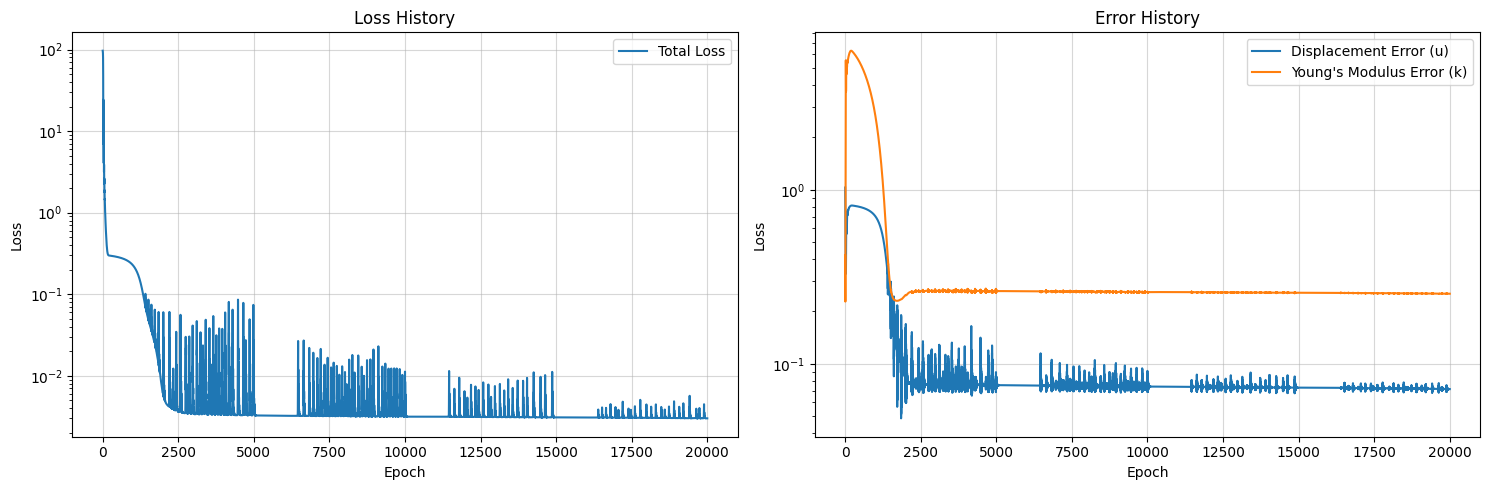

In [7]:
#error plots
def plot_loss(loss_list, ax, title="Loss"):
    ax.semilogy(loss_list, label=title)
    ax.grid(True, linestyle='-', alpha=0.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(loc="upper right")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_loss(loss_history, axes[0], title="Total Loss")
plot_loss(error_u_history, axes[1], title="Displacement Error (u)")
plot_loss(error_k_history, axes[1], title="Young's Modulus Error (k)")
axes[1].set_title("Error History")
axes[0].set_title("Loss History")
plt.tight_layout()
plt.show()

In [8]:
#saving plots for comparison
x_query = x_test.to(device)
u_query = u_model(x_query).detach().cpu()
k_query = k_model(x_query).detach().cpu()
x_query, x_test = x_query.cpu(), x_test.cpu()

#prediction u
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_query, u_query, label=rf"Pred. u", linewidth=2.0)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u$")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(f"plot_u_pred.pdf")
plt.close(fig)

#true u plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_test, u_test, label=rf"True $u$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u$")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(f"plot_u_true.pdf")
plt.close(fig)

#predictin k plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_query, k_query, label=rf"Pred. k", linewidth=2.0)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$k$")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(f"plot_k_pred.pdf")
plt.close(fig)

#true k plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_test, k_test, label=rf"True $k$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$k$")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(f"plot_k_true.pdf")
plt.close(fig)

#pointwise u
fig, ax = plt.subplots(figsize=(6, 4))
u_query = u_query.view(-1)
u_test = u_test.view(-1)
abs_error = torch.abs(u_test - u_query)
ax.semilogy(x_query, abs_error, label="Pointwise absolute error")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$|u_{{pred}} - u_{{true}}|$")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(f"u_pointwise_absolute_error.pdf")
plt.close(fig)

#pointwise k
fig, ax = plt.subplots(figsize=(6, 4))
k_query = k_query.view(-1)
k_test = k_test.view(-1)
abs_error = torch.abs(k_test - k_query)
ax.semilogy(x_query, abs_error, label="Pointwise absolute error")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$|k_{{pred}} - k_{{true}}|$")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(f"k_pointwise_absolute_error.pdf")
plt.close(fig)

print("\nFinal Result")
print("Relative L2 error in u:", error_u_history[-1])
print("Relative L2 error in k:", error_k_history[-1])


Final Result
Relative L2 error in u: 0.07163642346858978
Relative L2 error in k: 0.2529045343399048
